In [24]:
import seaborn as sns
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import(r2_score, mean_squared_error, accuracy_score, confusion_matrix,
classification_report, f1_score, roc_auc_score, average_precision_score)

from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Fetch file id on Drive
file_id = "1fNiz9QRSD5drWAs3k1Ji09D_u3COOJWR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "bank_transactions.csv", quiet=True)

# Load url
bank_df = pd.read_csv("bank_transactions.csv")

<br></br>

### Logistic Regression

In [8]:
# Set features and target
X = bank_df[["AccountBalance","CustomerAge","TransactionAmount","TransactionDuration", "LoginAttempts",
             "Location", "Channel", "CustomerOccupation"]]
y = bank_df["TransactionType"]

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Spit/train data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

# Normalize numeric features
num_feat = ["AccountBalance","CustomerAge","TransactionAmount","TransactionDuration", "LoginAttempts"]
scaler = StandardScaler() # to initialize scaler
X_train[num_feat] = scaler.fit_transform(X_train[num_feat])
X_test[num_feat] = scaler.fit_transform(X_test[num_feat])

In [9]:
# Logistic model
logistic = LogisticRegression(class_weight = "balanced",max_iter=1000)

# fit logistic
logistic.fit(X_train, y_train)

# Predict
log_pred = logistic.predict(X_test)

print("Logistic Regression Results")
print("***********************************************")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Results
***********************************************
Accuracy: 0.5519
              precision    recall  f1-score   support

      Credit       0.31      0.79      0.44      2251
       Debit       0.89      0.48      0.63      7749

    accuracy                           0.55     10000
   macro avg       0.60      0.64      0.53     10000
weighted avg       0.76      0.55      0.58     10000



<br></br>

### Random Forest

In [10]:
# Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Performance Results:

Accuracy: 1.0
              precision    recall  f1-score   support

      Credit       1.00      1.00      1.00      2251
       Debit       1.00      1.00      1.00      7749

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



/tmp/ipykernel_919/2805841264.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(feature_importance, x="Importance", y="Feature", palette="Greens_r", edgecolor= "black")


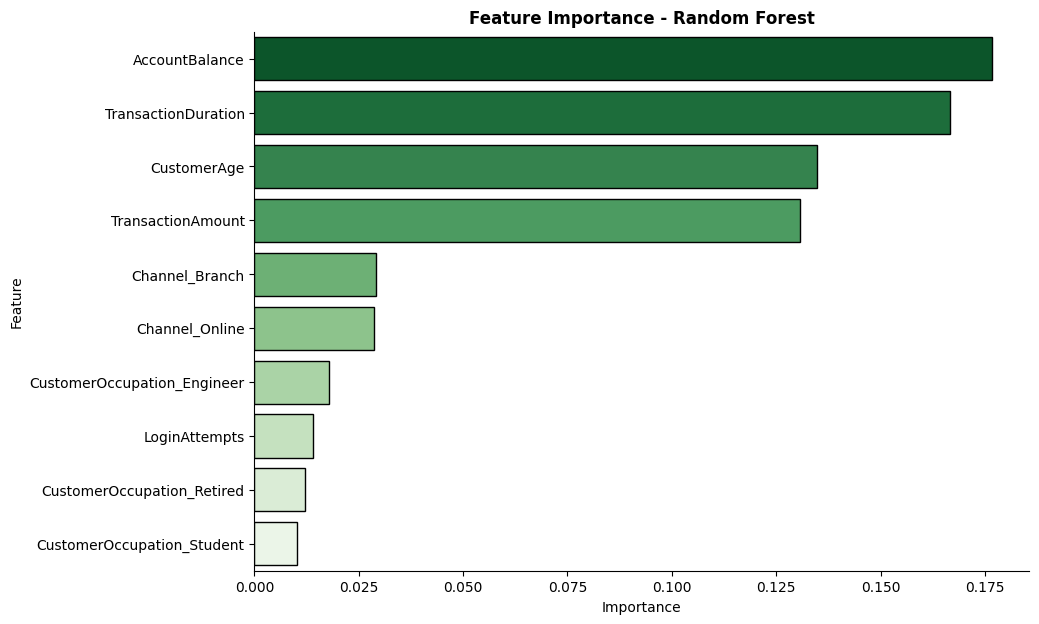

In [11]:
# Create dataframe for importance features
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values("Importance", ascending=False).head(10)

# Barplot
plt.figure(figsize=(10,7))
sns.barplot(feature_importance, x="Importance", y="Feature", palette="Greens_r", edgecolor= "black")
plt.title("Feature Importance - Random Forest", fontweight="bold")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

<br></br>

### XGBoost


In [17]:


# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify= y_encoded)

# Model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

# Fit
xgb.fit(X_train, y_train)

# Predict
xgb_pred = xgb.predict(X_test)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("***************************************************************")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))


XGBoost Accuracy: 0.9565
***************************************************************
              precision    recall  f1-score   support

      Credit       1.00      0.81      0.89      2251
       Debit       0.95      1.00      0.97      7749

    accuracy                           0.96     10000
   macro avg       0.97      0.90      0.93     10000
weighted avg       0.96      0.96      0.95     10000



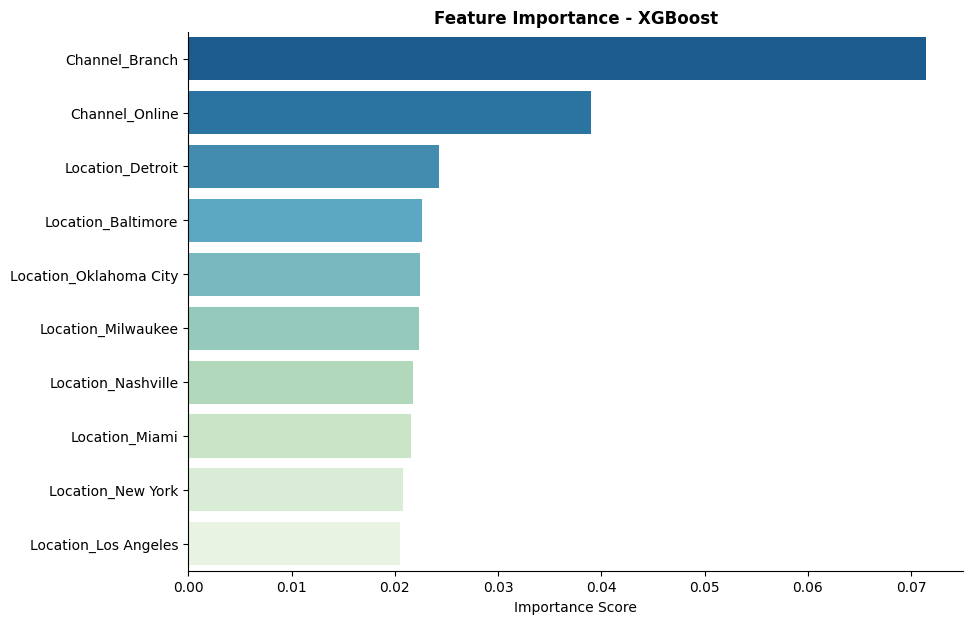

In [27]:
# Create dataframe for xgb feature importance
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

# Sort by importance with only first 10 values
feature_importance_xgb = feature_importance_xgb.sort_values("Importance", ascending=False).head(10)

# plot feature importance
plt.figure(figsize=(10,7))
sns.barplot(feature_importance_xgb, x="Importance", y="Feature", palette="GnBu_r")
plt.title("Feature Importance - XGBoost", fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()